<a href="https://colab.research.google.com/github/kalashjain9/Python-Notes/blob/main/Python_Notes_Day_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas Deep Dive: Functions, Columns, Saving, and Outliers

This notebook covers the following topics in pandas:

- Applying functions (`apply`, `map`)
- Creating and modifying columns
- Saving data to CSV and Excel
- Detecting outliers using the IQR method


In [ ]:
import pandas as pd

##  Modifying Columns

In pandas, columns can be created or updated directly using assignment. This is useful when you want to add new calculated features or modify existing ones.




### Creating New Columns

You can create new columns using a formula, function, or static value.

In [ ]:
df = pd.DataFrame({
    'item_price': [100, 250, 300],
    'quantity': [2, 1, 4]
})

# Create a new column for total price
df['total'] = df['item_price'] * df['quantity']
print(df)


   item_price  quantity  total
0         100         2    200
1         250         1    250
2         300         4   1200


### Updating Existing Columns

You can overwrite an existing column with new values.


In [ ]:
# Increase all item prices by 10%
df['item_price'] = df['item_price'] * 1.10
print(df)


   item_price  quantity  total
0       110.0         2    200
1       275.0         1    250
2       330.0         4   1200


### Using `apply()`

`.apply()` lets you run a function on each element in a column (or row, if you specify `axis=1`). It's like saying: “For each item in this column, do this thing.”



- Example 1

In [ ]:
# Sample dataset
df = pd.DataFrame({
    'price': [100, 200, 300, 400]
})

# Apply a function to double each price
df['new_price'] = df['price'].apply(lambda x: x / 2)
print(df)

   price  new_price
0    100       50.0
1    200      100.0
2    300      150.0
3    400      200.0


- Example 2

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'item': ['Pizza', 'Burger', 'Fries', 'Water Bottle', 'Mint', 'Pasta'],
    'price': [200, 150, 100, 50, 150, 300]
})


### Task:
You want to **square the price** of all dishes.


In [ ]:
df['price_squared'] = df['price'].apply(lambda x: x ** 2)
print(df)

           item  price  price_squared
0         Pizza    200          40000
1        Burger    150          22500
2         Fries    100          10000
3  Water Bottle     50           2500
4          Mint    150          22500
5         Pasta    300          90000


### TRY THIS NOW

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'item': ['Pizza', 'Burger', 'Fries', 'Water Bottle', 'Mint', 'Pasta'],
    'price': [200, 150, 100, 'free', None, 300]
})


### Our Previous solution on this question

In [ ]:
df['price_tripled'] = df['price'].apply(lambda x: x * 3)
print(df)


TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

### Solution for None

In [ ]:
df['price_tripled'] = df['price'].apply(lambda x: x * 3 if x != None else x)
print(df)

           item price price_tripled
0         Pizza   200           600
1        Burger   150           450
2         Fries   100           300
3  Water Bottle  free  freefreefree
4          Mint  None          None
5         Pasta   300           900


### Solution for free price

In [ ]:
df['price_tripled'] = df['price'].apply(lambda x: x * 3 if type(x) == int else x)
print(df)

           item price price_tripled
0         Pizza   200           600
1        Burger   150           450
2         Fries   100           300
3  Water Bottle  free          free
4          Mint  None          None
5         Pasta   300           900


### 🔹 Using `map()`

`.map()` is another way to transform a column. It's especially useful when you want to **map** specific values to other values.




In [ ]:
df = pd.DataFrame({
    'rating': ['bad', 'good', 'great', 'good']
})

In [ ]:
df['rating_score'] = df['rating'].map({
    'bad': 1,
    'good': 2,
    'great': 3
})

print(df)

  rating  rating_score
0    bad             1
1   good             2
2  great             3
3   good             2


### 🧪 Dataset:

Imagine you're analyzing customer reviews for a food delivery app. Each review has a text label — but users have typed them in different ways: some in lowercase, some with extra spaces, some with typos.

```python
import pandas as pd

df = pd.DataFrame({
    'review': ['Good', 'bad', 'Excellent', 'Bad', ' good ', 'average', 'EXCELLENT', 'mediocre']
})
```

### 🧠 Goal:
Convert reviews to a **rating score** using a mapping:
- Excellent → 5
- Good → 4
- Average → 3
- Bad → 2
- Anything else → 1


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'review': ['Good', 'bad', 'Excellent', 'Bad', ' good ', 'average', 'EXCELLENT', 'mediocre']
})


### Solution - Will this work?

In [ ]:
rating_map = {
    'Excellent': 5,
    'Good': 4,
    'Average': 3,
    'Bad': 2
}

df['score'] = df['review'].map(rating_map)
print(df)


      review  score
0       Good    4.0
1        bad    NaN
2  Excellent    5.0
3        Bad    2.0
4      good     NaN
5    average    NaN
6  EXCELLENT    NaN
7   mediocre    NaN


### Better Solution

In [ ]:
df['review_cleaned'] = df['review'].str.title().str.strip()
df['score'] = df['review_cleaned'].map(rating_map)
print(df)


      review  score review_cleaned
0       Good    4.0           Good
1        bad    2.0            Bad
2  Excellent    5.0      Excellent
3        Bad    2.0            Bad
4      good     4.0           Good
5    average    3.0        Average
6  EXCELLENT    5.0      Excellent
7   mediocre    NaN       Mediocre


### Further solution

In [ ]:
df['score'] = df['score'].fillna(1)
print(df)

      review review_cleaned  score
0       Good           Good    4.0
1        bad            Bad    2.0
2  Excellent      Excellent    5.0
3        Bad            Bad    2.0
4      good            Good    4.0
5    average        Average    3.0
6  EXCELLENT      Excellent    5.0
7   mediocre       Mediocre    1.0


## 💾 3. Saving Data (CSV & Excel)

After cleaning or processing a dataset, it’s common to save it for future use.






### Saving as CSV

In [ ]:
# Save DataFrame to CSV file
df.to_csv('cleaned_data.csv', index=False)

- `index=False` is used to avoid saving the index as a column in the CSV file.


### Saving as Excel


In [ ]:
# Save DataFrame to Excel file
df.to_excel('cleaned_data.xlsx', index=False)


##  4. Detecting Outliers with IQR

Outliers are data points that are significantly different from others. A common method to detect them is the **Interquartile Range (IQR)** method.

- Net worth of Indian citizens and Ambani is also in that Data

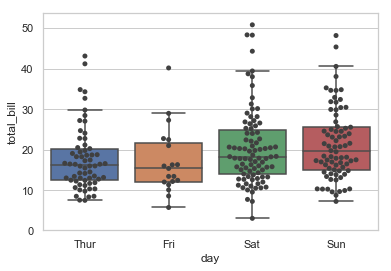

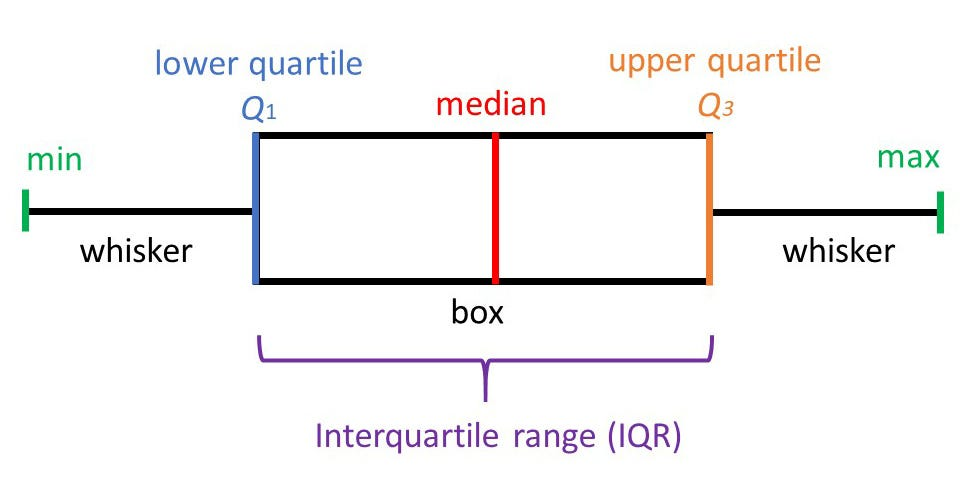

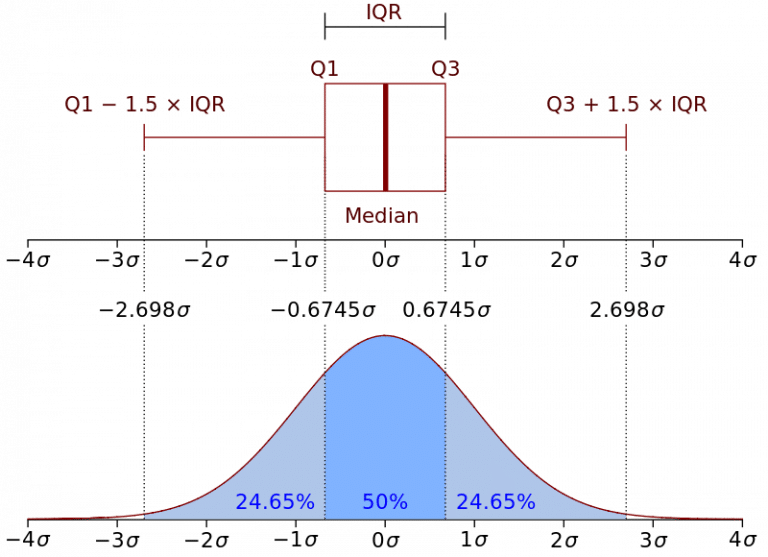

### What is IQR?

- **Q1**: 25th percentile (lower quartile)
- **Q3**: 75th percentile (upper quartile)
- **IQR** = Q3 - Q1 (This is where 50% of the values lie)
- **Lower bound** = Q1 - 1.5 * IQR
- **Upper bound** = Q3 + 1.5 * IQR


Any data point outside this range is considered an outlier.
- This technique is particularly useful in data cleaning, where unusually high or low values can skew analysis.


In [ ]:
df = pd.DataFrame({
    'delivery_time': [5, 30, 35, 32, 31, 100, 98, 40, 33, 29, 34]
})


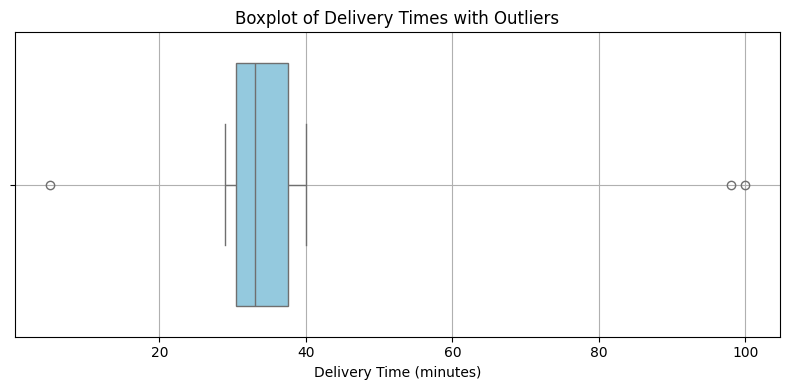

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['delivery_time'], color='skyblue')
plt.title('Boxplot of Delivery Times with Outliers')
plt.xlabel('Delivery Time (minutes)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# Calculate Q1 and Q3
Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)


Q1: 30.5
Q3: 37.5
IQR: 7.0
Lower Bound: 20.0
Upper Bound: 48.0


In [ ]:
outliers = df[(df['delivery_time'] < lower) | (df['delivery_time'] > upper)]
print("Outliers:")
print(outliers)

Outliers:
   delivery_time
0              5
5            100
6             98


## Summary


| Concept | Method |
|--------|--------|
| Apply function to column | `df['col'].apply(lambda x: ...)` |
| Map values | `df['col'].map({'a':1, 'b':2})` |
| Create column | `df['new_col'] = ...` |
| Update column | `df['col'] = ...` |
| Save CSV | `df.to_csv('file.csv')` |
| Save Excel | `df.to_excel('file.xlsx')` |
| Detect outliers | Use IQR method with `quantile()` |


# *THANK U*

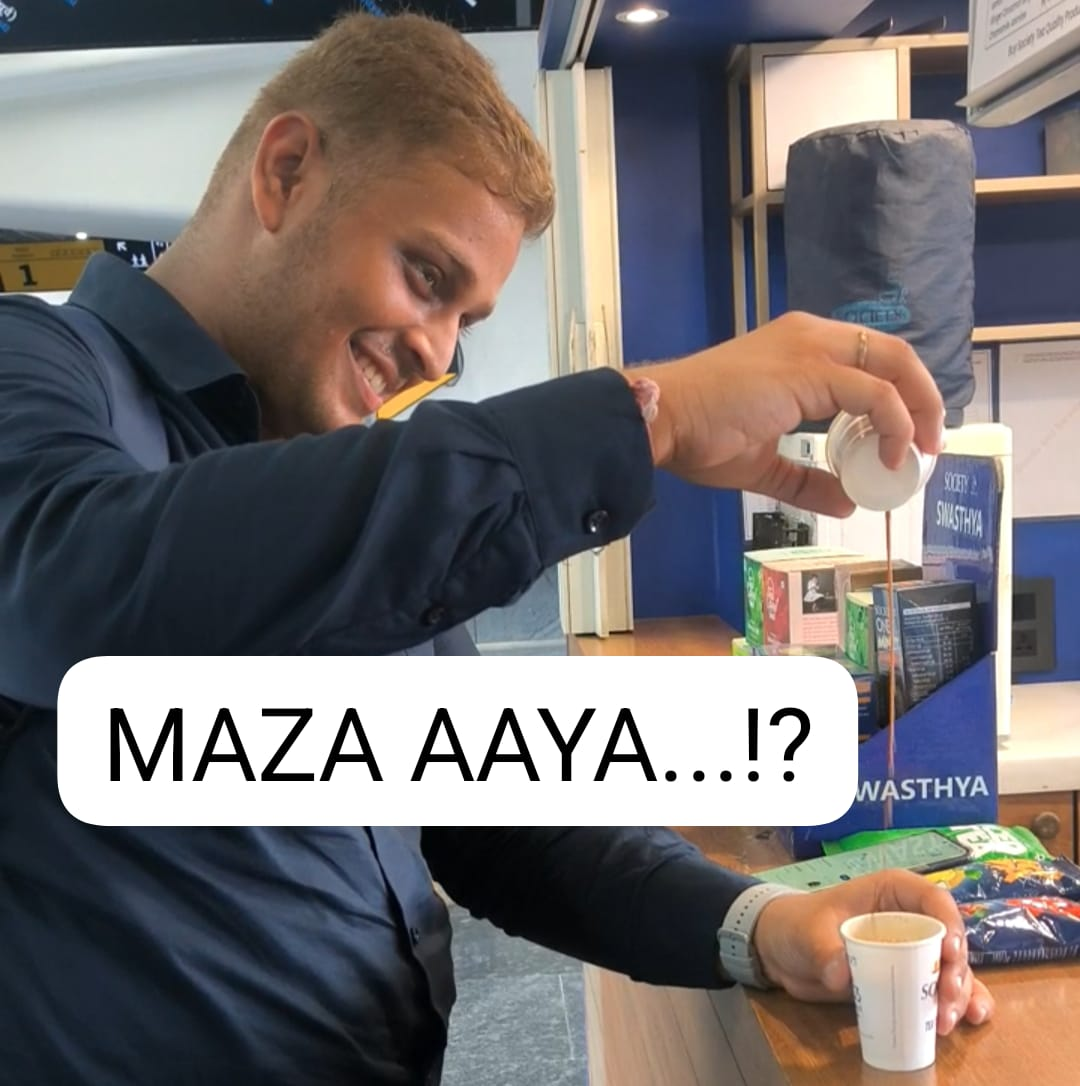

# HOMEWORK

Complete the following exercises to reinforce your understanding of applying functions, modifying columns, saving files, and detecting outliers using Pandas. Use the code templates provided and build your solutions step by step.

---

## Question 1: Price Update and Clean-Up

You are managing data for a multi-brand store. The `price` column contains both numbers and strings like `'free'`, `'N/A'`, and `None`.

```python
import pandas as pd

df = pd.DataFrame({
    'product': ['Shampoo', 'Toothpaste', 'Soap', 'Face Wash', 'Towel'],
    'price': ['199', 'free', '89', None, 'N/A']
})
```

**Task:**
- Convert the `price` column to numeric. Invalid entries should become `NaN`.
- Create a new column `price_doubled` that doubles all valid prices.
- Print the cleaned DataFrame.

---

## Question 2: Discount Based on Category (with typos)

You're analyzing a grocery store's data. The category column has inconsistent values.

```python
df = pd.DataFrame({
    'item': ['Chips', 'Soda', 'Cookies', 'Juice', 'Tea'],
    'price': [50, 30, 80, 60, 40],
    'category': ['snack', 'Drink', 'Snack', 'drnk', 'DRINK']
})
```

**Task:**
- Standardize all values in the `category` column to lowercase.
- Apply a 10% discount only to items categorized as `'drink'`.
- Create a new column `discounted_price`.

---

## Question 3: Save Cleaned Data

Take the cleaned DataFrame from **Question 1**.

**Task:**
- Save the DataFrame as both a `.csv` file and a `.xlsx` file.
- Do not include the index in the saved files.
- Open both files and confirm:
  - That invalid values were saved as blank or `NaN`.
  - That the numeric values are preserved.

---

## Question 4: Map and Fill Missing Ratings

You're analyzing feedback data with missing values.

```python
df = pd.DataFrame({
    'review': ['Great', 'Poor', 'Okay', None, 'Excellent'],
    'user_rating': ['5', '1', None, '3', '5']
})
```

**Task:**
- Map the `review` text to a sentiment score using:
  ```python
  { 'Poor': 1, 'Okay': 2, 'Great': 4, 'Excellent': 5 }
  ```
- Convert the `user_rating` column to numeric.
- Fill the missing values in `user_rating` using the mapped sentiment score from `review`.

---

## Question 5: Detect Delivery Time Outliers

You are analyzing delivery times for a courier company.

```python
df = pd.DataFrame({
    'package_id': range(1, 11),
    'delivery_time': [45, 50, 48, 47, 300, 46, 44, 49, 43, 280]
})
```

**Task:**
- Calculate the IQR (Interquartile Range) for `delivery_time`.
- Determine the lower and upper bounds.
- Identify and display the outlier rows.
- Create a new DataFrame excluding the outliers.
